# Data Prep

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
calender_events =  pd.read_csv('calendar_events.csv')
df = df.merge( calender_events, on='date', how = 'left')
#df

,store_id,store_name,date,revenue,event
0,0,All Stores,2011-01-29,204126.52,NaN
1,0,All Stores,2011-01-30,197426.42,NaN
2,0,All Stores,2011-01-31,144267.27,NaN
3,0,All Stores,2011-02-01,151903.00,NaN
4,0,All Stores,2011-02-02,117399.88,NaN
...,...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55,NaN
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53,NaN
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53,NaN
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95,NaN


In [ ]:
#make events a binary yes or no
df['event_binary'] = df['event'].notna().astype(int)
#make features lagged
df = df.sort_values(['store_id', 'date'])

for lag in [1, 2, 7, 30, 90]:
    df[f'lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)


#features day of week and month 
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month


features = ['event_binary', 'lag_1', 'lag_2', 'day_of_week', 'month','lag_week' ,'lag_month', 'lag_quarter' ]


# #tomorrws revenue
# df['target_daily'] = df.groupby('store_id')['revenue'].shift(-1)
# #todays revenue 
# df['target_monthly'] = df.groupby('store_id')['revenue'].shift(-30)



,store_id,store_name,date,revenue_today,event,event_binary,lag_1,lag_2,lag_week,lag_month,lag_quarter,day_of_week,month,lag_7,lag_30,lag_90
0,0,All Stores,2011-01-29,204126.52,NaN,0,NaN,NaN,NaN,NaN,NaN,5,1,NaN,NaN,NaN
1,0,All Stores,2011-01-30,197426.42,NaN,0,204126.52,NaN,NaN,NaN,NaN,6,1,NaN,NaN,NaN
2,0,All Stores,2011-01-31,144267.27,NaN,0,197426.42,204126.52,NaN,NaN,NaN,0,1,NaN,NaN,NaN
3,0,All Stores,2011-02-01,151903.00,NaN,0,144267.27,197426.42,NaN,NaN,NaN,1,2,NaN,NaN,NaN
4,0,All Stores,2011-02-02,117399.88,NaN,0,151903.00,144267.27,NaN,NaN,NaN,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55,NaN,0,21475.47,17646.33,28280.03,17735.05,23104.83,5,9,28280.03,17735.05,23104.83
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53,NaN,0,25689.55,21475.47,28233.15,20053.50,18231.20,6,9,28233.15,20053.50,18231.20
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53,NaN,0,26557.53,25689.55,19653.90,23304.33,17573.20,0,9,19653.90,23304.33,17573.20
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95,NaN,0,19067.53,26557.53,17487.03,24047.72,20421.38,1,9,17487.03,24047.72,20421.38


In [44]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def train_test_split_90(store_df):
    store_df   = store_df.sort_values('date')
    split_date = store_df['date'].max() - pd.Timedelta(days=90)
    train      = store_df[store_df['date'] <= split_date]
    test       = store_df[store_df['date'] >  split_date]
    return train, test, split_date

# ── 3. HORIZON-SHIFTED TRAINING DATA ────────────────────────────────────────

def make_horizon_df(store_df, horizon):
    """
    Target becomes revenue `horizon` days into the future.
    Features are the same lagged features from the current row.
    """
    d = store_df.copy()
    d['target'] = d['revenue'].shift(-horizon)
    return d.dropna(subset=FEATURES + ['target'])

# ── 4. RECURSIVE PREDICTION HELPERS ─────────────────────────────────────────

def make_future_row(pred_date, last_known, event_calendar):
    def get_lag(n):
        target = pred_date - pd.Timedelta(days=n)
        return last_known.get(target, np.nan)

    return {
        'date':         pred_date,
        'event_binary': event_calendar.get(pred_date, 0),
        'lag_1':        get_lag(1),
        'lag_2':        get_lag(2),
        'lag_week':     get_lag(7),
        'lag_month':    get_lag(30),
        'lag_quarter':  get_lag(90),
        'day_of_week':  pred_date.dayofweek,
        'month':        pred_date.month,
    }


def recursive_predict(model, horizon_days, last_known, start_date, event_calendar):
    preds   = []
    running = dict(last_known)

    for i in range(horizon_days):
        pred_date = start_date + pd.Timedelta(days=i)
        row       = make_future_row(pred_date, running, event_calendar)
        X         = pd.DataFrame([row])[FEATURES]
        y_hat     = model.predict(X)[0]
        running[pred_date] = y_hat
        preds.append((pred_date, y_hat))

    return preds


def recursive_predict_chunked(model, total_days, chunk_size, last_known,
                               start_date, event_calendar):
    """
    Predict in blocks of chunk_size days.
    Each completed chunk is written back to running before the next chunk starts.
    Daily  (chunk=1)  → predicts 1 day, feeds back, repeats
    Monthly(chunk=30) → predicts 30 days, feeds back whole block, repeats
    Quarterly(chunk=90)→ predicts all 90 days in one shot
    """
    all_preds     = []
    running       = dict(last_known)
    current_start = start_date
    days_left     = total_days

    while days_left > 0:
        chunk       = min(chunk_size, days_left)
        chunk_preds = recursive_predict(model, chunk, running,
                                        current_start, event_calendar)
        for date, val in chunk_preds:
            running[date] = val
        all_preds.extend(chunk_preds)
        current_start += pd.Timedelta(days=chunk)
        days_left     -= chunk

    return all_preds

# ── 5. TRAIN 3 MODELS PER STORE & EVALUATE ──────────────────────────────────

XGB_PARAMS = dict(
    n_estimators    = 300,
    learning_rate   = 0.05,
    max_depth       = 6,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    n_jobs          = -1,
)

store_models  = {}  # {store_name: {'daily': model, 'monthly': model, 'quarterly': model}}
store_results = {}  # {store_name: {'daily': df, 'monthly': df, 'quarterly': df}}

MODEL_CONFIGS = [
    ('daily',     1,  1),   # (name, training horizon, prediction chunk size)
    ('monthly',  30, 30),
    ('quarterly',90, 90),
]

for store_name, group in df.groupby('store_name'):
    group      = group.sort_values('date').reset_index(drop=True)
    train_df, test_df, split_date = train_test_split_90(group)

    last_known = dict(zip(train_df['date'], train_df['revenue']))
    event_cal  = dict(zip(group['date'],    group['event_binary']))
    test_start = test_df['date'].min()

    print(f"\n{'='*65}")
    print(f"Store : {store_name}")
    print(f"Train : up to {split_date.date()}  |  "
          f"Test  : {test_start.date()} → {test_df['date'].max().date()}  "
          f"({len(test_df)} rows)")

    models  = {}
    results = {}

    for model_name, train_horizon, chunk_size in MODEL_CONFIGS:

        # Each model trained to predict a different horizon ahead
        train_h = make_horizon_df(train_df, train_horizon)
        X_train = train_h[FEATURES]
        y_train = train_h['target']

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, verbose=False)

        # All 3 models predict the same 90-day test window
        preds = recursive_predict_chunked(
            model          = model,
            total_days     = 90,
            chunk_size     = chunk_size,
            last_known     = last_known,
            start_date     = test_start,
            event_calendar = event_cal,
        )

        pred_df = pd.DataFrame(preds, columns=['date', 'pred_revenue'])
        merged  = test_df[['date', 'revenue']].merge(pred_df, on='date', how='inner')

        mae  = mean_absolute_error(merged['revenue'], merged['pred_revenue'])
        rmse = mean_squared_error(merged['revenue'],  merged['pred_revenue']) ** 0.5
        mape = (((merged['revenue'] - merged['pred_revenue']).abs()
                 / merged['revenue'].replace(0, np.nan)).mean()) * 100

        print(f"  [{model_name:>10}]  "
              f"MAE={mae:>10,.0f}   RMSE={rmse:>10,.0f}   MAPE={mape:>6.1f}%")

        models[model_name]  = model
        results[model_name] = pred_df

    store_models[store_name]  = models
    store_results[store_name] = results

print(f"\n{'='*65}")
print("Done. Outputs:")
print("  store_models  → {store_name: {'daily', 'monthly', 'quarterly'}}")
print("  store_results → {store_name: {'daily', 'monthly', 'quarterly'}} (pred DataFrames)")



Store : All Stores
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=    35,932   RMSE=    45,714   MAPE=  11.5%
  [   monthly]  MAE=    53,506   RMSE=    63,018   MAPE=  17.2%
  [ quarterly]  MAE=    43,607   RMSE=    56,608   MAPE=  13.7%

Store : California – Golden Hills
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=     5,875   RMSE=     7,413   MAPE=  11.2%
  [   monthly]  MAE=     9,943   RMSE=    11,290   MAPE=  19.1%
  [ quarterly]  MAE=    11,649   RMSE=    13,685   MAPE=  22.1%

Store : California – Ocean View
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     daily]  MAE=     9,137   RMSE=    11,515   MAPE=  27.0%
  [   monthly]  MAE=    10,553   RMSE=    13,650   MAPE=  29.7%
  [ quarterly]  MAE=    10,746   RMSE=    13,192   MAPE=  31.0%

Store : California – Redwood Center
Train : up to 2015-07-02  |  Test  : 2015-07-03 → 2015-09-30  (90 rows)
  [     dai

In [45]:
store_results['All Stores']['daily']

,date,pred_revenue
0,2015-07-03,335646.437500
1,2015-07-04,331970.750000
2,2015-07-05,301456.375000
3,2015-07-06,263824.718750
4,2015-07-07,261413.171875
...,...,...
85,2015-09-26,337315.875000
86,2015-09-27,271425.906250
87,2015-09-28,239653.531250
88,2015-09-29,254462.750000


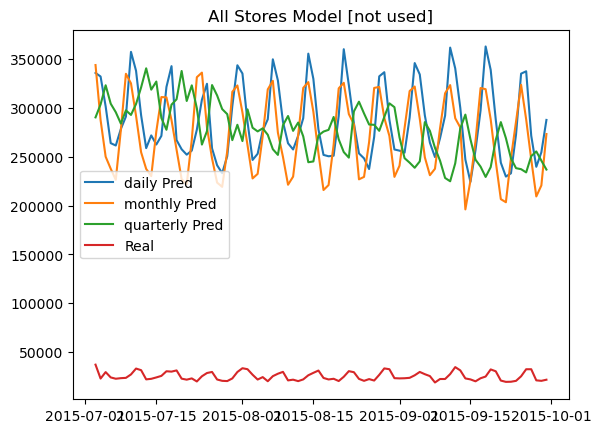

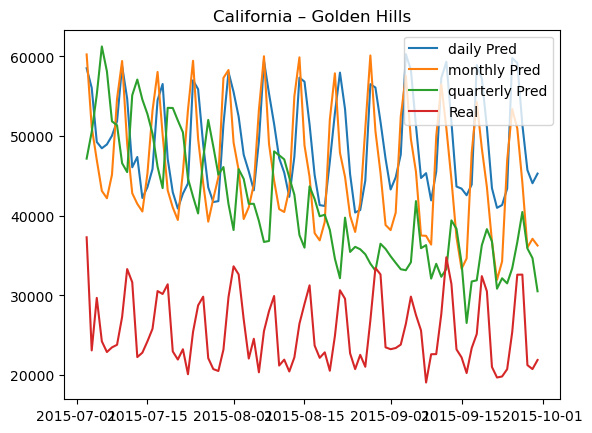

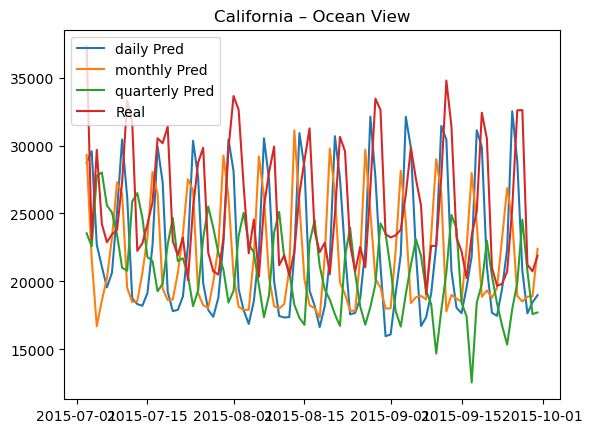

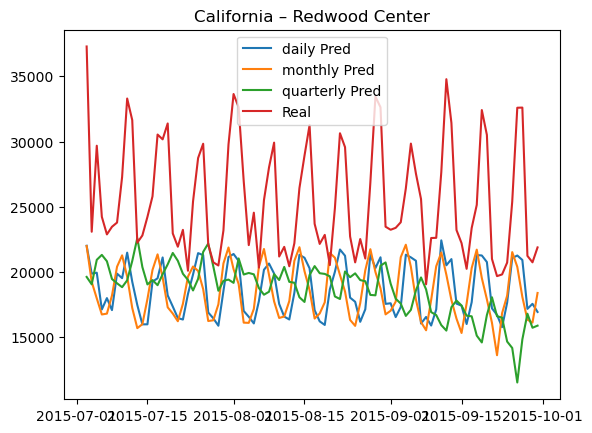

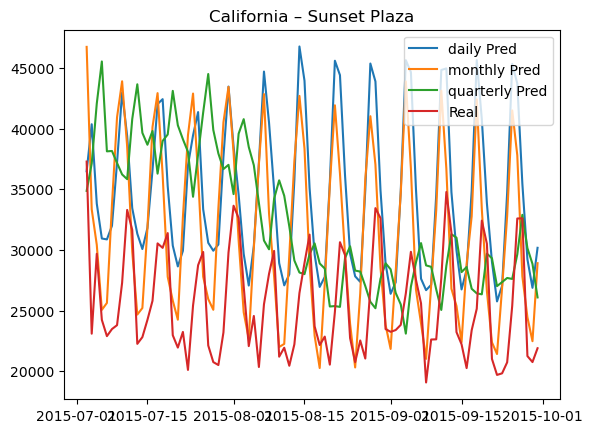

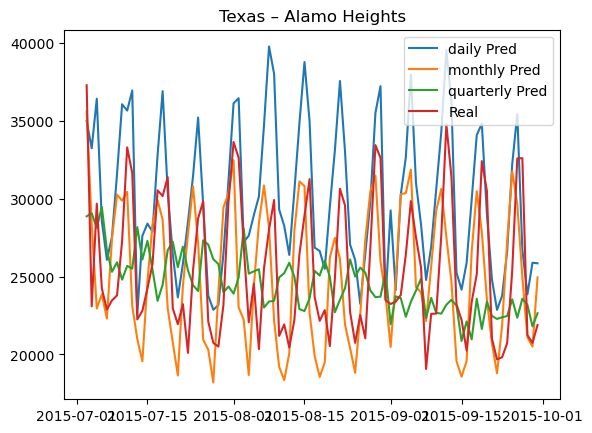

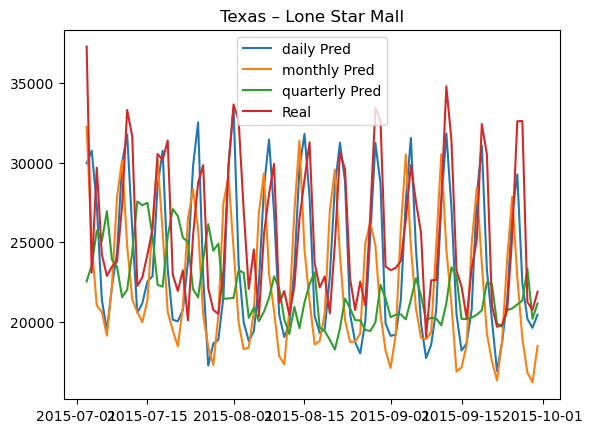

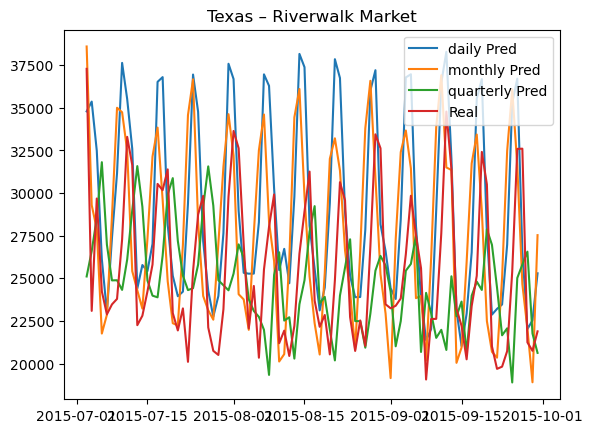

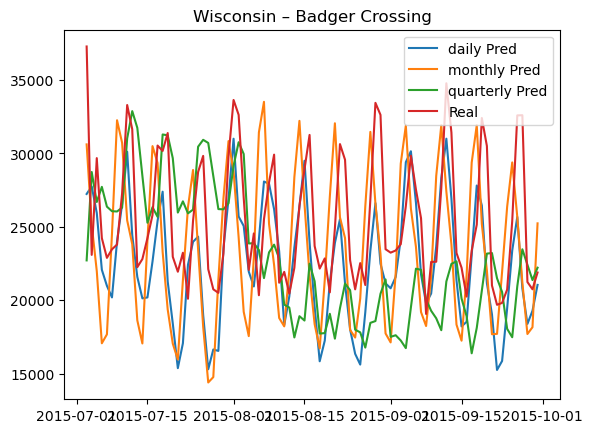

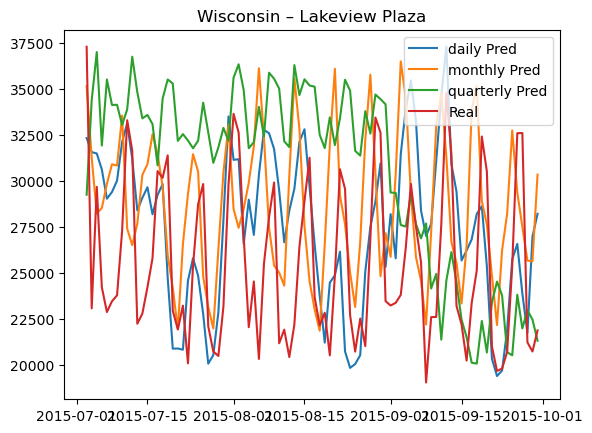

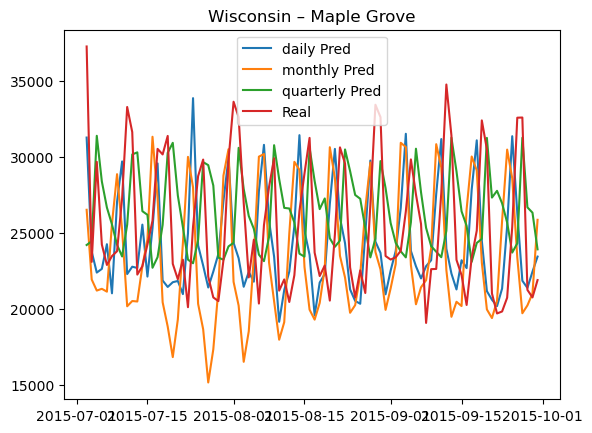

In [ ]:
import matplotlib.pyplot as plt


for store in store_results:
    if store == 'All Stores': 
        plt.title('All Stores Model [not used]')
    else:
        plt.title(store)
    pred = store_results[store]
    
    for period in pred:
        plt.plot(pred[period]['date'], pred[period]['pred_revenue'], label = f'{period} Pred')
    plt.plot(test_df['date'], test_df['revenue'], label = 'Real')
    plt.legend()
    plt.show()
    


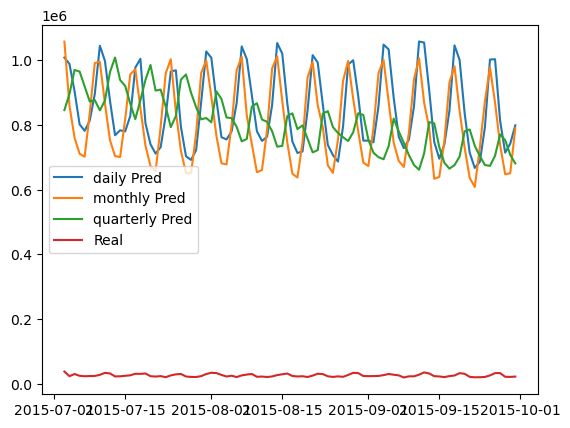

In [51]:
all_preds = {}
for model_name in ['daily', 'monthly', 'quarterly']:
    combined = (pd.concat([store_results[s][model_name] 
                           for s in store_results])
                  .groupby('date')['pred_revenue']
                  .sum()
                  .reset_index())
    all_preds[model_name] = combined

all_preds
for period in all_preds:
    plt.plot(all_preds[period]['date'], all_preds[period]['pred_revenue'], label = f'{period} Pred')
plt.plot(test_df['date'], test_df['revenue'], label = 'Real')
plt.legend()
plt.show()



P